# Comparação entre métricas normadas e a distância intrínseca no grafo de ruas

**Estudo de caso:** Ciclo Básico Unicamp → Terminal Barão Geraldo, seguido de um experimento estatístico com 10.000 pares de vértices em Campinas.

Este notebook usa o pacote `nao_e_so_reta`, que concentra as funções de download/carregamento do grafo, projeção métrica, cálculo de menor caminho, cálculo das métricas $L^p$, amostragem de pares, estatísticas de erro e geração de gráficos.

A ideia matemática é comparar a distância intrínseca do grafo de ruas,

$$d_G(u,v) = \min_{\gamma:u\to v}\sum_{e\in \gamma}\ell(e),$$

com distâncias induzidas por normas em $\mathbb{R}^2$:

$$d_p(x,y)=\left(|x_1-y_1|^p+|x_2-y_2|^p\right)^{1/p},$$

incluindo os casos $p=1$, $p=2$, $p=1.54$, outros valores fixos de $p$, e $p=\infty$:

$$d_\infty(x,y)=\max\{|x_1-y_1|, |x_2-y_2|\}.$$

As coordenadas são projetadas para um CRS métrico antes do cálculo das distâncias planas. Isso é essencial: latitude/longitude estão em graus, não em metros.

## 1. Instalação

In [13]:
from pathlib import Path
import sys
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import nao_e_so_reta as sm

print(f"Diretório do projeto: {PROJECT_ROOT}")


Diretório do projeto: /home/ABTLUS/thalles24006/Documentos/ILUM/PGMAT/nao-e-so-reta


## 2. Configuração geral do experimento

O experimento tem dois níveis:

1. **Caso pontual:** Ciclo Básico Unicamp → Terminal Barão Geraldo.
2. **Caso estatístico:** 10.000 pares de vértices em Campinas.

Para rodar mais rápido durante testes, reduza `N_PAIRS` para algo como `500` ou `1000`. Depois volte para `10_000` na execução final.

In [14]:
# Lugares principais
PLACE_CASE = "Barão Geraldo, Campinas, São Paulo, Brazil"
PLACE_STATS = "Campinas, São Paulo, Brazil"

# Pontos do estudo de caso
ORIGIN_QUERY = "Rua Sérgio Buarque de Holanda, 290, Barão Geraldo, Campinas, São Paulo, Brazil"
DESTINATION_QUERY = "R. Alzira de Águiar Aranha, S/N, Jardim Santa Genebra II, Campinas, São Paulo, Brazil"

# Fallbacks.
# Formato: (latitude, longitude).
ORIGIN_FALLBACK_LATLON = (-22.817528, -47.068611)
DESTINATION_FALLBACK_LATLON = (-22.83065, -47.07957)

# Fallback aproximado para baixar um recorte de Barão Geraldo caso PLACE_CASE não resolva como polígono.
# O valor é usado somente se o download por nome falhar.
BARAO_CENTER_LATLON = (-22.8170, -47.0700)
BARAO_DIST_M = 6500

# Rede abstrata de ruas: baixamos a rede de ruas veiculares e depois ignoramos direção das vias.
NETWORK_TYPE = "drive"
MAKE_UNDIRECTED = True

# Valores fixos de p, incluindo p = 1.54.
P_VALUES = sm.DEFAULT_P_VALUES

# Experimento estatístico
N_PAIRS = 10_000
N_ORIGINS = 250
SEED = 42


## 3. Download ou carregamento do grafo de Barão Geraldo

O grafo salvo em `data/graph_barao_geraldo.graphml` é o grafo bruto do OSMnx. Sempre que ele é carregado, o módulo reprojeta o grafo para coordenadas métricas, converte para não direcionado e mantém a maior componente conexa.

Se o nome `Barão Geraldo, Campinas, São Paulo, Brazil` não resolver como polígono no Nominatim, o código tenta baixar um recorte circular com centro e raio definidos acima.


In [15]:
graph_barao_path = "../data/graph.graphml"

try:
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        place=PLACE_CASE,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
    print("Grafo de Barão Geraldo carregado por nome de lugar.")
except Exception as exc:
    print("Falha ao carregar Barão Geraldo por nome de lugar.")
    print("Erro:", repr(exc))
    print("Tentando recorte por ponto central + raio...")
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        center_point=BARAO_CENTER_LATLON,
        dist=BARAO_DIST_M,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
        force_download=True,
    )

print(f"Número de vértices: {len(G_barao.nodes):,}")
print(f"Número de arestas: {len(G_barao.edges):,}")
print("CRS:", G_barao.graph.get("crs"))

Grafo de Barão Geraldo carregado por nome de lugar.
Número de vértices: 2,181
Número de arestas: 3,265
CRS: EPSG:32723


## 4. Grafo para o experimento estatístico

Agora carregamos Campinas inteira. Dependendo da máquina e da conexão, este passo pode ser mais pesado que o recorte de Barão Geraldo.

Se quiser fazer um teste rápido só em Barão Geraldo, substitua `PLACE_STATS` por `PLACE_CASE` ou simplesmente use `G_stats = G_barao` na célula seguinte.

In [16]:
USE_CAMPINAS_FOR_STATS = False

if USE_CAMPINAS_FOR_STATS:
    graph_stats_path = "../data/graph.graphml"
    G_stats = sm.load_or_download_graph(
        graph_stats_path,
        place=PLACE_STATS,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
else:
    graph_stats_path = graph_barao_path
    G_stats = G_barao

print(f"Grafo estatístico: {PLACE_STATS if USE_CAMPINAS_FOR_STATS else PLACE_CASE}")
print(f"Número de vértices: {len(G_stats.nodes):,}")
print(f"Número de arestas: {len(G_stats.edges):,}")
print("CRS:", G_stats.graph.get("crs"))

Grafo estatístico: Barão Geraldo, Campinas, São Paulo, Brazil
Número de vértices: 2,181
Número de arestas: 3,265
CRS: EPSG:32723


## 5. Amostragem de 10.000 pares de vértices

A amostragem usa `N_ORIGINS` origens distintas e vários destinos por origem. Isso reduz o custo computacional, porque o menor caminho é calculado por Dijkstra uma vez por origem, não uma vez por par.

Com `N_PAIRS = 10_000` e `N_ORIGINS = 250`, serão feitas aproximadamente 250 execuções de Dijkstra.

In [17]:
pairs = sm.sample_vertex_pairs(
    G_stats,
    n_pairs=N_PAIRS,
    n_origins=N_ORIGINS,
    seed=SEED,
)

pairs_path = "results/sampled_pairs.csv"
sm.save_dataframe(pairs, pairs_path)

print(pairs.head())
print(f"Total de pares: {len(pairs):,}")
print(f"Origens distintas: {pairs['origin'].nunique():,}")
print("Pares salvos em:", pairs_path)

       origin      target
0  3956688544  8272765180
1  1037596119  1040638098
2   993367306  1037621686
3  5189491687  1067977697
4   999517562  8269957475
Total de pares: 10,000
Origens distintas: 250
Pares salvos em: results/sampled_pairs.csv


## 6. Cálculo de $d_G$ e das métricas $L^p$

Esta é a etapa computacional central. O resultado está salvo em `results/results_10000_pairs.csv`.

In [18]:
t0 = time.perf_counter()

results = sm.compute_pair_metrics(
    G_stats,
    pairs,
    p_values=P_VALUES,
    show_progress=True,
)

elapsed = time.perf_counter() - t0

results_path = "results/results_10000_pairs.csv"
sm.save_dataframe(results, results_path)

print(f"Cálculo concluído em {elapsed/60:.2f} minutos.")
print(f"Resultados salvos em: {results_path}")
results

Cálculo concluído em 0.04 minutos.
Resultados salvos em: results/results_10000_pairs.csv


,origin,target,origin_x,origin_y,target_x,target_y,d_graph_m,d_L1_m,d_L1_25_m,d_L1_5_m,d_L1_54_m,d_L1_75_m,d_L2_m,d_L3_m,d_L5_m,d_L10_m,d_Linf_m,tortuosity_dG_dL2
0,3956688544,8272765180,289340.608224,7.472708e+06,286278.917314,7.474711e+06,4898.692611,5064.764429,4433.311928,4063.813108,4018.764571,3824.452468,3658.723104,3324.310225,3131.801048,3066.061353,3061.690910,1.338908
1,1037596119,1040638098,284192.903044,7.474743e+06,287604.655265,7.471797e+06,6184.740322,6357.343661,5538.110614,5052.609553,4992.863323,4733.006217,4507.389726,4026.294024,3689.882770,3483.149812,3411.752221,1.372133
2,993367306,1037621686,287804.572866,7.476140e+06,287298.141385,7.475054e+06,2061.923091,1593.057261,1410.132327,1306.355097,1293.984490,1241.660373,1198.844623,1122.121135,1091.363035,1086.678308,1086.625780,1.719925
3,5189491687,1067977697,289390.626846,7.472201e+06,286791.796652,7.477922e+06,7582.138101,8319.371365,7371.678852,6835.618853,6771.854737,6502.642675,6283.192633,5894.015369,5742.511429,5720.755347,5720.541171,1.206733
4,999517562,8269957475,285895.447948,7.478939e+06,289175.218190,7.471018e+06,9491.168962,11200.990781,9963.928368,9272.112710,9190.493090,8848.288704,8573.367347,8104.376746,7940.406119,7921.337834,7921.220540,1.107053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1040637699,1067977776,288168.854893,7.471032e+06,287416.782449,7.478449e+06,9395.859565,8169.402545,7754.940764,7576.135138,7558.507692,7494.251374,7455.360406,7419.906491,7417.345998,7417.330101,7417.330101,1.260282
9996,8273361862,1040539220,288109.509598,7.470970e+06,287529.968087,7.471075e+06,743.074108,684.787090,633.882359,609.068624,606.409955,596.094983,589.020369,580.696176,579.564402,579.541513,579.541511,1.261542
9997,1013918976,1003137786,285273.614095,7.474432e+06,286349.904166,7.473177e+06,2149.186937,2331.030051,2030.766924,1852.850480,1830.958463,1735.752423,1653.110019,1477.012902,1354.206139,1279.483552,1254.739980,1.300087
9998,1407116987,998956888,284619.540101,7.474782e+06,288058.339498,7.471566e+06,5810.170107,6654.058251,5793.511448,5282.819659,5219.909123,4946.038408,4707.784064,4196.519551,3830.345474,3583.621510,3438.799397,1.234162


## 7. Resumo dos erros

As métricas de comparação usadas aqui são:

$$MAE = \frac{1}{n}\sum_{i=1}^n |d_G^{(i)} - d_p^{(i)}|,$$

$$MAPE = \frac{100}{n}\sum_{i=1}^n \frac{|d_G^{(i)} - d_p^{(i)}|}{d_G^{(i)}}.$$

Como estamos fazendo comparação direta, não há calibração multiplicativa do tipo $\alpha_p d_p$.


In [19]:
summary = sm.summarize_metric_errors(results, p_values=P_VALUES)
summary_path = "results/summary_metric_errors.csv"
sm.save_dataframe(summary, summary_path)

print("Ranking por MAPE:")
display(summary[["metric", "p", "MAE_m", "MAPE_percent", "mean_dG_over_metric", "median_dG_over_metric"]])

Ranking por MAPE:


,metric,p,MAE_m,MAPE_percent,mean_dG_over_metric,median_dG_over_metric
0,L1,1.00,592.509238,14.066117,1.101745,1.042911
1,L1_25,1.25,694.900422,16.156843,1.214904,1.155324
2,L1_5,1.50,865.315371,19.863345,1.289698,1.228641
3,L1_54,1.54,890.075175,20.407719,1.299240,1.238705
4,L1_75,1.75,997.348435,22.808307,1.341362,1.278240
5,L2,2.00,1085.787249,24.837788,1.378393,1.313560
6,L3,3.00,1246.440401,28.628866,1.455415,1.384403
7,L5,5.00,1326.334198,30.562503,1.502332,1.425671
8,L10,10.00,1358.134931,31.350003,1.524860,1.444497
9,Linf,inf,1368.044563,31.596831,1.533083,1.447026


## 8. Tortuosidade

A tortuosidade principal será:

$$\tau_i = \frac{d_G^{(i)}}{d_2^{(i)}}.$$

Ela mede quanto a distância caminhando pela rede de ruas excede a distância euclidiana entre os mesmos vértices.

In [20]:
tortuosity_summary = sm.summarize_tortuosity(results)
tortuosity_summary_path = "results/tortuosity_summary.csv"
tortuosity_summary.to_frame("valor").to_csv(tortuosity_summary_path)

tortuosity_summary

n         10000.000000
mean          1.378393
std           0.377684
min           0.998222
p05           1.083949
median        1.313560
p95           1.837838
max          17.170879
dtype: float64

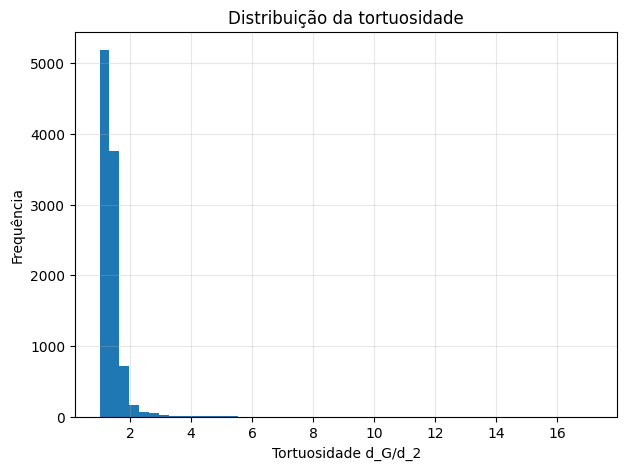

Figura salva em: results/tortuosidade_hist.png


In [21]:
tort_fig_path = "results/tortuosidade_hist.png"
fig, ax = sm.plot_tortuosity_hist(
    results,
    bins=50,
    filepath=tort_fig_path,
)
plt.show()
print("Figura salva em:", tort_fig_path)

## 9. Busca numérica do melhor $p$

Agora avaliamos uma grade de valores de $p$ entre 1 e 10. Esta etapa não recalcula menores caminhos; ela reaproveita as coordenadas dos pares e a coluna `d_graph_m` já calculada.

Por padrão, usamos passo `0.01`:

$p = 1.00, 1.01, 1.02, \ldots, 5.00.$

In [22]:
P_GRID = sm.p_grid(1.0, 5.0, 0.01)

grid_results = sm.evaluate_p_grid(
    results,
    P_GRID,
)

grid_results_path = "results/p_grid_results.csv"
sm.save_dataframe(grid_results, grid_results_path)

best_by_mape = sm.best_p_by(grid_results, criterion="MAPE_percent")
best_by_mae = sm.best_p_by(grid_results, criterion="MAE_m")

print("Melhor p por MAPE:")
display(best_by_mape.to_frame().T)

print("Melhor p por MAE:")
display(best_by_mae.to_frame().T)

Melhor p por MAPE:


,p,n,MAE_m,MAPE_percent,RMSE_m,bias_m
3,1.03,10000.0,591.28445,14.006391,812.908921,-296.540385


Melhor p por MAE:


,p,n,MAE_m,MAPE_percent,RMSE_m,bias_m
2,1.02,10000.0,591.051714,14.011466,811.471071,-275.699026


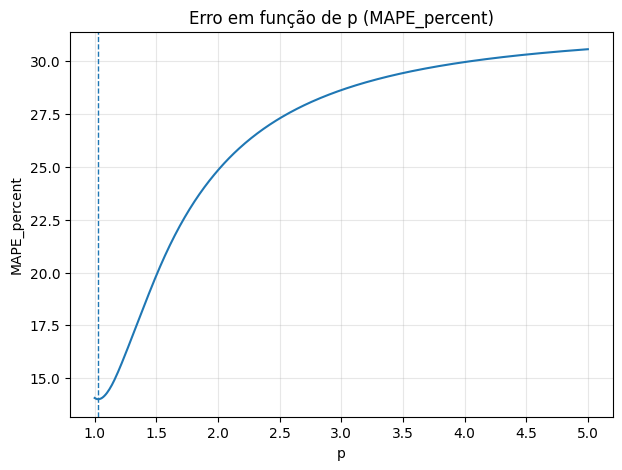

Figura salva em: figures/mape_por_p.png


In [23]:
error_p_fig_path = "figures/mape_por_p.png"
fig, ax = sm.plot_error_by_p(
    grid_results,
    criterion="MAPE_percent",
    filepath=error_p_fig_path,
)
plt.show()
print("Figura salva em:", error_p_fig_path)

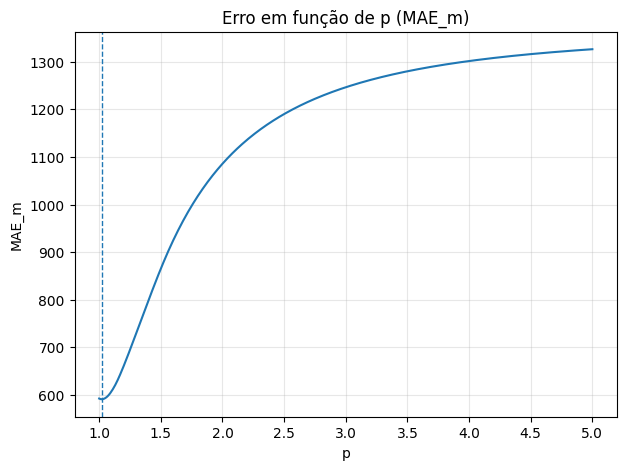

Figura salva em: figures/mae_por_p.png


In [24]:
mae_p_fig_path = "figures/mae_por_p.png"
fig, ax = sm.plot_error_by_p(
    grid_results,
    criterion="MAE_m",
    filepath=mae_p_fig_path,
)
plt.show()
print("Figura salva em:", mae_p_fig_path)

## 10. Gráficos de dispersão

Cada gráfico compara uma distância plana com a distância intrínseca no grafo. A linha tracejada é a identidade $y=x$. Pontos acima da linha indicam que a distância no grafo é maior que a métrica plana, o que é esperado para $d_2$ quando os caminhos do grafo são curvas poligonais no plano.

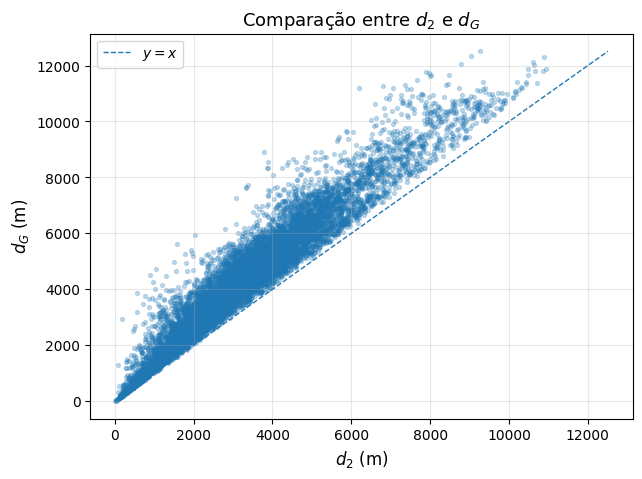

Figura salva em: figures/scatter_L2_vs_dG.png


In [25]:
scatter_l2_path = "figures/scatter_L2_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results,
    sm.metric_column_from_p(2.0),
    filepath=scatter_l2_path,
)
plt.show()
print("Figura salva em:", scatter_l2_path)

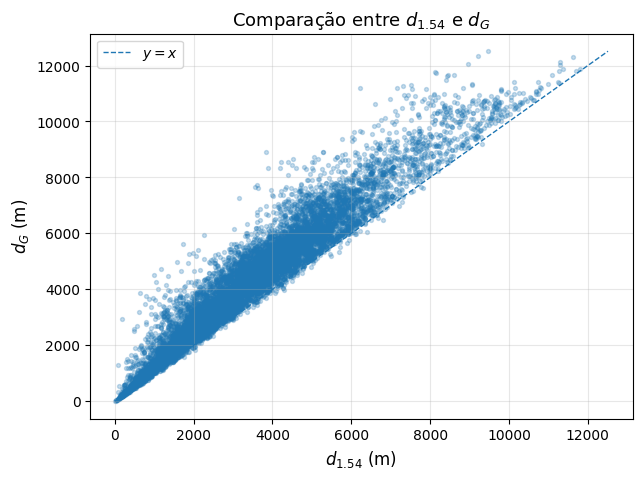

Figura salva em: figures/scatter_L1_54_vs_dG.png


In [26]:
scatter_l154_path = "figures/scatter_L1_54_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results,
    sm.metric_column_from_p(1.54),
    filepath=scatter_l154_path,
)
plt.show()
print("Figura salva em:", scatter_l154_path)

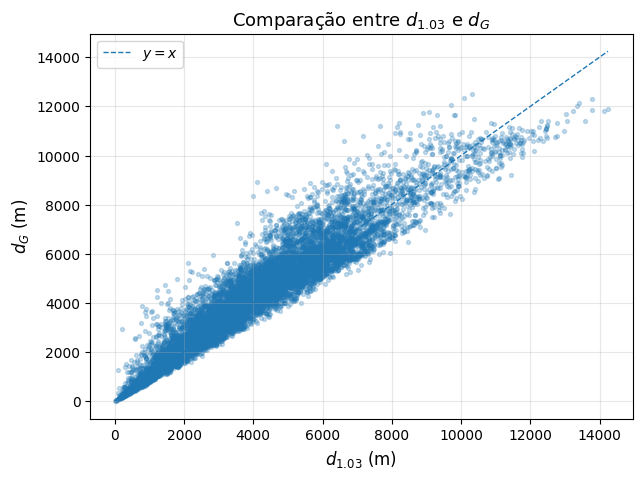

Melhor p por MAPE: 1.03
Figura salva em: figures/scatter_best_p_vs_dG.png


In [27]:
# Adiciona coluna para o melhor p por MAPE, se ele não estiver entre os p fixos.
best_p = float(best_by_mape["p"])
best_col = sm.metric_column_from_p(best_p)

if best_col not in results.columns:
    results_best = sm.add_lp_columns(results, p_values=[best_p])
else:
    results_best = results

scatter_best_path = "figures/scatter_best_p_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results_best,
    best_col,
    filepath=scatter_best_path,
)
plt.show()
print(f"Melhor p por MAPE: {best_p:.2f}")
print("Figura salva em:", scatter_best_path)

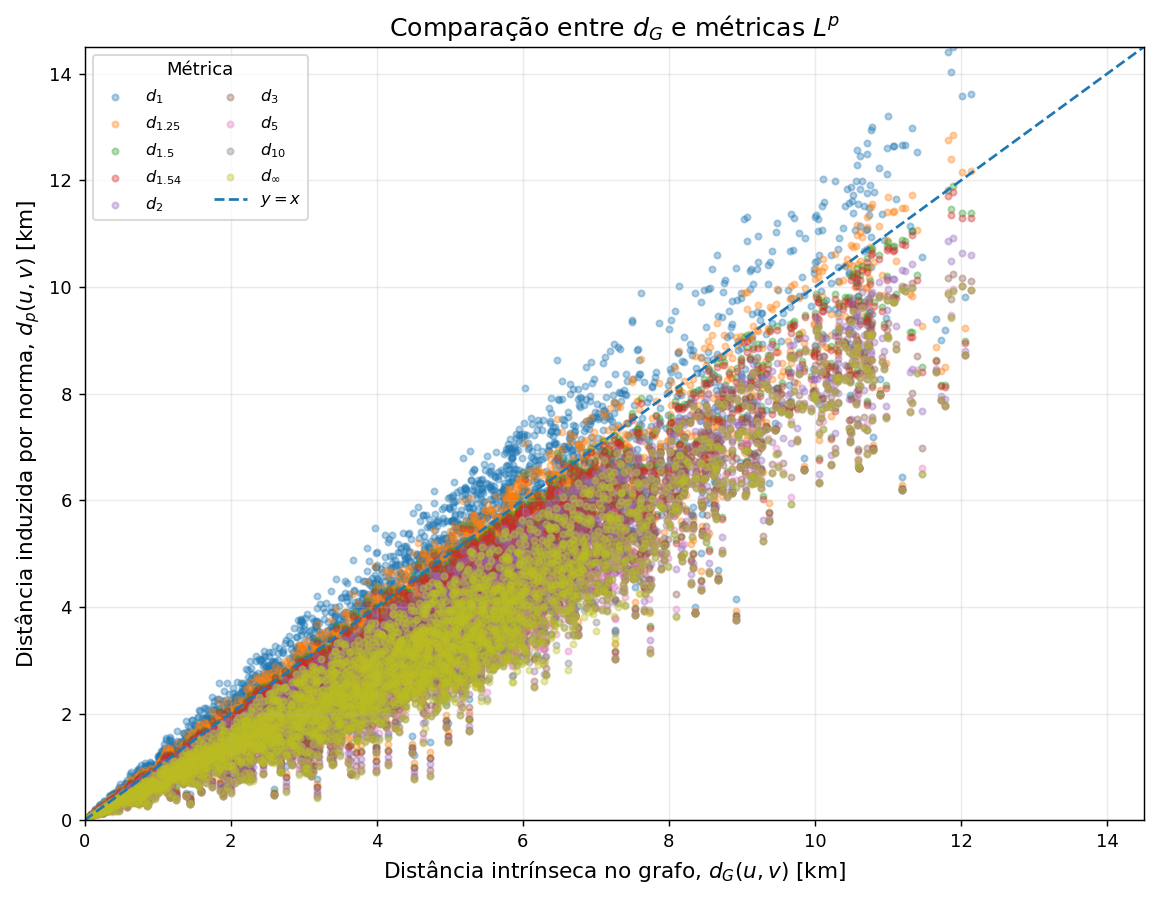

In [28]:
# Métricas que você quer comparar contra d_G.
metric_specs = [
    (sm.metric_column_from_p(1.0), r"$d_1$"),
    (sm.metric_column_from_p(1.25), r"$d_{1.25}$"),
    (sm.metric_column_from_p(1.5), r"$d_{1.5}$"),
    (sm.metric_column_from_p(1.54), r"$d_{1.54}$"),
    (sm.metric_column_from_p(2.0), r"$d_2$"),
    (sm.metric_column_from_p(3.0), r"$d_3$"),
    (sm.metric_column_from_p(5.0), r"$d_5$"),
    (sm.metric_column_from_p(10.0), r"$d_{10}$"),
    (sm.metric_column_from_p(math.inf), r"$d_\infty$"),
]

# Remove métricas que eventualmente não estejam no DataFrame.
metric_specs = [(col, label) for col, label in metric_specs if col in results.columns]

# Opcional: amostra pontos para o gráfico não ficar visualmente saturado.
# O cálculo estatístico continua usando todos os 10.000 pares.
plot_df = results.copy()

if len(plot_df) > 4000:
    plot_df = plot_df.sample(4000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7), dpi=130)

x = plot_df["d_graph_m"] / 1000  # km

for col, label in metric_specs:
    y = plot_df[col] / 1000  # km
    ax.scatter(
        x,
        y,
        s=12,
        alpha=0.35,
        label=label,
    )

# Linha de referência y = x.
lim_max = max(
    plot_df["d_graph_m"].max(),
    max(plot_df[col].max() for col, _ in metric_specs),
) / 1000

ax.plot(
    [0, lim_max],
    [0, lim_max],
    linestyle="--",
    linewidth=1.5,
    label=r"$y=x$",
)

ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)

ax.set_xlabel(r"Distância intrínseca no grafo, $d_G(u,v)$ [km]", fontsize=12)
ax.set_ylabel(r"Distância induzida por norma, $d_p(u,v)$ [km]", fontsize=12)
ax.set_title(r"Comparação entre $d_G$ e métricas $L^p$", fontsize=14)

ax.grid(True, alpha=0.25)
ax.legend(title=r"Métrica", fontsize=9, title_fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

Interpretação matemática inicial

Alguns pontos para usar na redação do artigo:

1. A distância euclidiana \(d_2\) entre dois vértices é um limite inferior natural para a distância no grafo quando as arestas do grafo representam segmentos ou curvas no plano com comprimento físico. Intuitivamente, qualquer caminho pela rede é um caminho admissível no plano, e o segmento reto é o menor caminho euclidiano.

2. A tortuosidade \(d_G/d_2\) mede o excesso imposto pela malha viária: quão mais longo é o deslocamento na rede em relação à separação euclidiana.

3. As métricas \(L^1\), \(L^p\) e \(L^\infty\) dependem da orientação dos eixos. Em uma malha urbana com direções predominantes, certos valores de \(p\) podem se ajustar melhor à geometria empírica do grafo.

4. Como a comparação aqui é direta, sem calibração multiplicativa, a métrica vencedora é aquela cuja escala e geometria bruta mais se aproximam de \(d_G\) para a amostra escolhida.

5. O valor ótimo de \(p\) deve ser interpretado empiricamente: ele não prova que a cidade “é” um espaço \(L^p\), mas indica qual norma da família \(L^p\) minimiza o erro escolhido sob a amostra e o recorte espacial utilizados.

## Referências práticas usadas no notebook

- OSMnx: biblioteca para baixar, modelar, projetar, analisar e visualizar redes urbanas a partir do OpenStreetMap.
- NetworkX: biblioteca usada para os algoritmos de menor caminho, incluindo Dijkstra em grafos ponderados.
- Ciclo Básico Unicamp: endereço oficial na Rua Sérgio Buarque de Holanda, nº 290.
- Terminal Barão Geraldo – Lázaro de Campos Faria: terminal em Barão Geraldo, Campinas.